687976

===== AVAILABLE DATE RANGE IN OPTIONS FILE =====
Option data min date: 2022-08-29
Option data max date: 2025-08-29

===== 30D IMPLIED BORROW COST SERIES =====
      date     exdate  dte_days  spot  strike  call_mid  put_mid  call_delta  put_delta  borrow_cost
2024-11-11 2024-12-20        39 44.07    44.0     3.500    3.475    0.534771  -0.460679     0.054536
2024-11-12 2024-12-20        38 43.98    45.0     3.350    4.450    0.496803  -0.497653     0.063618
2024-11-13 2024-12-20        37 42.92    44.0     3.250    4.450    0.494657  -0.498714     0.073884
2024-11-14 2024-12-20        36 42.88    44.0     2.975    4.100    0.476607  -0.526088     0.047366
2024-11-15 2024-12-20        35 45.87    47.0     3.275    4.250    0.499190  -0.502051     0.010775
2024-11-18 2024-12-20        32 44.20    44.0     2.750    3.100    0.521850  -0.471563     0.188185
2024-11-19 2024-12-20        31 45.80    52.0     1.850    8.850    0.310617  -0.654498     0.259496
2024-11-20 2024-12-20    

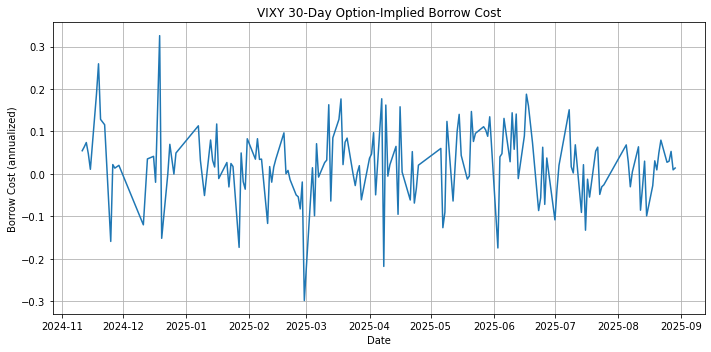

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 30-DAY OPTION-IMPLIED BORROW COST FOR VIXY
#
# Formula from your note:
#   C - P = S * exp(-BC*T) - K * exp(-r*T)
#
# Solve for borrow cost BC:
#   BC = -(1/T) * ln( (C - P + K*exp(-r*T)) / S )
#
# Goal here:
#   For each trade date, choose the SAME-STRIKE call/put pair with
#   expiry closest to 30 calendar days and ATM by delta:
#       call delta ~ +0.50
#       put  delta ~ -0.50
#
# Then compute the implied borrow cost for that 30D pair.
#
# IMPORTANT:
#   Your uploaded options file only spans 2024-08-29 to 2025-08-29.
#   So this script will only produce results over that available range.
# ============================================================

OPT_FILE = "b10xheebr3v3h1vn.csv"
SPOT_FILE = "HistoricalData_1774985169796.csv"

TARGET_DTE = 30
MIN_DTE = 20
MAX_DTE = 45
FLAT_RF = 0.045          # continuous annual rate; replace if you have a Treasury series
MAX_SPREAD_PCT = 0.50    # remove very wide quotes
USE_DELTA_ATM = True

# Optional user range
START_DATE = "2022-08-29"
END_DATE   = "2025-08-29"

# ------------------------------------------------------------
# Load Yahoo spot data
# ------------------------------------------------------------
spot = pd.read_csv(SPOT_FILE).copy()
spot["Date"] = pd.to_datetime(spot["Date"])

close_col = "Close/Last" if "Close/Last" in spot.columns else "Close"
spot["spot"] = (
    spot[close_col]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

spot = (
    spot[["Date", "spot"]]
    .rename(columns={"Date": "date"})
    .sort_values("date")
    .drop_duplicates("date")
)

spot = spot[
    (spot["date"] >= pd.to_datetime(START_DATE)) &
    (spot["date"] <= pd.to_datetime(END_DATE))
].copy()

# ------------------------------------------------------------
# Load raw option data
# ------------------------------------------------------------
opt = pd.read_csv(OPT_FILE, low_memory=False).copy()
opt["date"] = pd.to_datetime(opt["date"])
opt["exdate"] = pd.to_datetime(opt["exdate"])

# Restrict to requested range
opt = opt[
    (opt["date"] >= pd.to_datetime(START_DATE)) &
    (opt["date"] <= pd.to_datetime(END_DATE))
].copy()


# Basic quality filters
opt = opt[
    (opt["contract_size"] == 100) &
    opt["best_bid"].notna() &
    opt["best_offer"].notna() &
    opt["delta"].notna()
].copy()

opt = opt[opt["best_offer"] >= opt["best_bid"]].copy()

opt["mid"] = (opt["best_bid"] + opt["best_offer"]) / 2.0
opt["strike"] = opt["strike_price"] / 1000.0
opt["dte_days"] = (opt["exdate"] - opt["date"]).dt.days
opt["T"] = opt["dte_days"] / 365.0

opt = opt[(opt["dte_days"] >= MIN_DTE) & (opt["dte_days"] <= MAX_DTE)].copy()

# Join spot
opt = opt.merge(spot, on="date", how="inner")

# Quote quality
opt["spread_pct"] = np.where(
    opt["mid"] > 0,
    (opt["best_offer"] - opt["best_bid"]) / opt["mid"],
    np.nan
)
opt = opt[(opt["mid"] > 0) & (opt["spread_pct"] <= MAX_SPREAD_PCT)].copy()

# ------------------------------------------------------------
# Build same-strike call-put pairs
# ------------------------------------------------------------
calls = opt[opt["cp_flag"] == "C"].copy()
puts  = opt[opt["cp_flag"] == "P"].copy()

calls = calls[[
    "date", "exdate", "strike", "dte_days", "T", "spot",
    "mid", "delta", "optionid"
]].rename(columns={
    "mid": "call_mid",
    "delta": "call_delta",
    "optionid": "call_id"
})

puts = puts[[
    "date", "exdate", "strike", "dte_days", "T", "spot",
    "mid", "delta", "optionid"
]].rename(columns={
    "mid": "put_mid",
    "delta": "put_delta",
    "optionid": "put_id"
})

pairs = calls.merge(
    puts,
    on=["date", "exdate", "strike", "dte_days", "T", "spot"],
    how="inner"
)

# ------------------------------------------------------------
# Pick the best 30D ATM pair for each trade date
#   1) choose expiry closest to 30 DTE
#   2) within that expiry choose ATM same-strike pair by delta
# ------------------------------------------------------------
if pairs.empty:
    raise ValueError(
        "No valid same-strike call/put pairs found in the requested date range. "
        "Your options file likely does not cover those dates."
    )

# Score expiries by closeness to 30D
expiry_choice = (
    pairs.groupby(["date", "exdate", "dte_days"], as_index=False)
    .size()
    .rename(columns={"size": "n_pairs"})
)
expiry_choice["dte_dist"] = (expiry_choice["dte_days"] - TARGET_DTE).abs()

best_expiry = (
    expiry_choice.sort_values(["date", "dte_dist", "dte_days"])
    .groupby("date", as_index=False)
    .first()[["date", "exdate", "dte_days"]]
)

pairs = pairs.merge(best_expiry, on=["date", "exdate", "dte_days"], how="inner")

# Score ATM-ness within chosen expiry
if USE_DELTA_ATM:
    pairs["atm_score"] = (pairs["call_delta"] - 0.50).abs() + (pairs["put_delta"] + 0.50).abs()
else:
    pairs["atm_score"] = (pairs["strike"] - pairs["spot"]).abs()

best_pair = (
    pairs.sort_values(["date", "atm_score", "strike"])
    .groupby("date", as_index=False)
    .first()
)

# ------------------------------------------------------------
# Compute 30D borrow cost
# ------------------------------------------------------------
best_pair["r"] = FLAT_RF

best_pair["parity_ratio"] = (
    best_pair["call_mid"]
    - best_pair["put_mid"]
    + best_pair["strike"] * np.exp(-best_pair["r"] * best_pair["T"])
) / best_pair["spot"]

# Keep economically valid rows
best_pair = best_pair[
    (best_pair["parity_ratio"] > 0) &
    np.isfinite(best_pair["parity_ratio"])
].copy()

best_pair["borrow_cost"] = -(1.0 / best_pair["T"]) * np.log(best_pair["parity_ratio"])

# Optional cleanup of noisy outliers
best_pair = best_pair[
    np.isfinite(best_pair["borrow_cost"]) &
    (best_pair["borrow_cost"] > -5.0) &
    (best_pair["borrow_cost"] < 5.0)
].copy()

# ------------------------------------------------------------
# Final 30D series
# ------------------------------------------------------------
borrow_30d = best_pair[[
    "date", "exdate", "dte_days", "spot", "strike",
    "call_mid", "put_mid", "call_delta", "put_delta",
    "borrow_cost"
]].sort_values("date").reset_index(drop=True)

print("\n===== AVAILABLE DATE RANGE IN OPTIONS FILE =====")
print(f"Option data min date: {opt['date'].min().date() if not opt.empty else 'N/A'}")
print(f"Option data max date: {opt['date'].max().date() if not opt.empty else 'N/A'}")

print("\n===== 30D IMPLIED BORROW COST SERIES =====")
print(borrow_30d.head(20).to_string(index=False))

print("\n===== SUMMARY =====")
print(borrow_30d["borrow_cost"].describe())

# ------------------------------------------------------------
# Plot the 30D borrow cost time series
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(borrow_30d["date"].to_numpy(), borrow_30d["borrow_cost"].to_numpy())
plt.title("VIXY 30-Day Option-Implied Borrow Cost")
plt.xlabel("Date")
plt.ylabel("Borrow Cost (annualized)")
plt.grid(True)
plt.tight_layout()
plt.show()




In [3]:
print("Using file:", OPT_FILE)
print("Min option date:", opt["date"].min())
print("Max option date:", opt["date"].max())

Using file: b10xheebr3v3h1vn.csv
Min option date: 2022-08-29 00:00:00
Max option date: 2025-08-29 00:00:00


In [6]:
print(borrow_30d["date"])

0     2024-11-11
1     2024-11-12
2     2024-11-13
3     2024-11-14
4     2024-11-15
         ...    
162   2025-08-25
163   2025-08-26
164   2025-08-27
165   2025-08-28
166   2025-08-29
Name: date, Length: 167, dtype: datetime64[ns]


In [7]:
print("raw:", opt["date"].min())

print("after basic filters:", opt1["date"].min())

print("after DTE filter:", opt2["date"].min())

print("after spot merge:", opt3["date"].min())

print("after same-strike pairing:", pairs["date"].min())

print("after best expiry:", pairs2["date"].min())

print("after parity filter:", best_pair2["date"].min())

raw: 2022-08-29 00:00:00
after basic filters: 2022-08-29 00:00:00
after DTE filter: 2022-08-29 00:00:00
after spot merge: 2022-08-29 00:00:00
after same-strike pairing: 2022-08-29 00:00:00
after best expiry: 2022-08-29 00:00:00
after parity filter: 2022-08-29 00:00:00
